# CATSA Random Subject Signal Plot

CATSA 데이터셋에서 무작위 피험자 1명을 선택해,
Baseline / Nback / Stroop / Sudoku 조건에서 ACC, BVP, EDA, HR, TEMP 신호를 시각화합니다.

Selected subject: Sub10


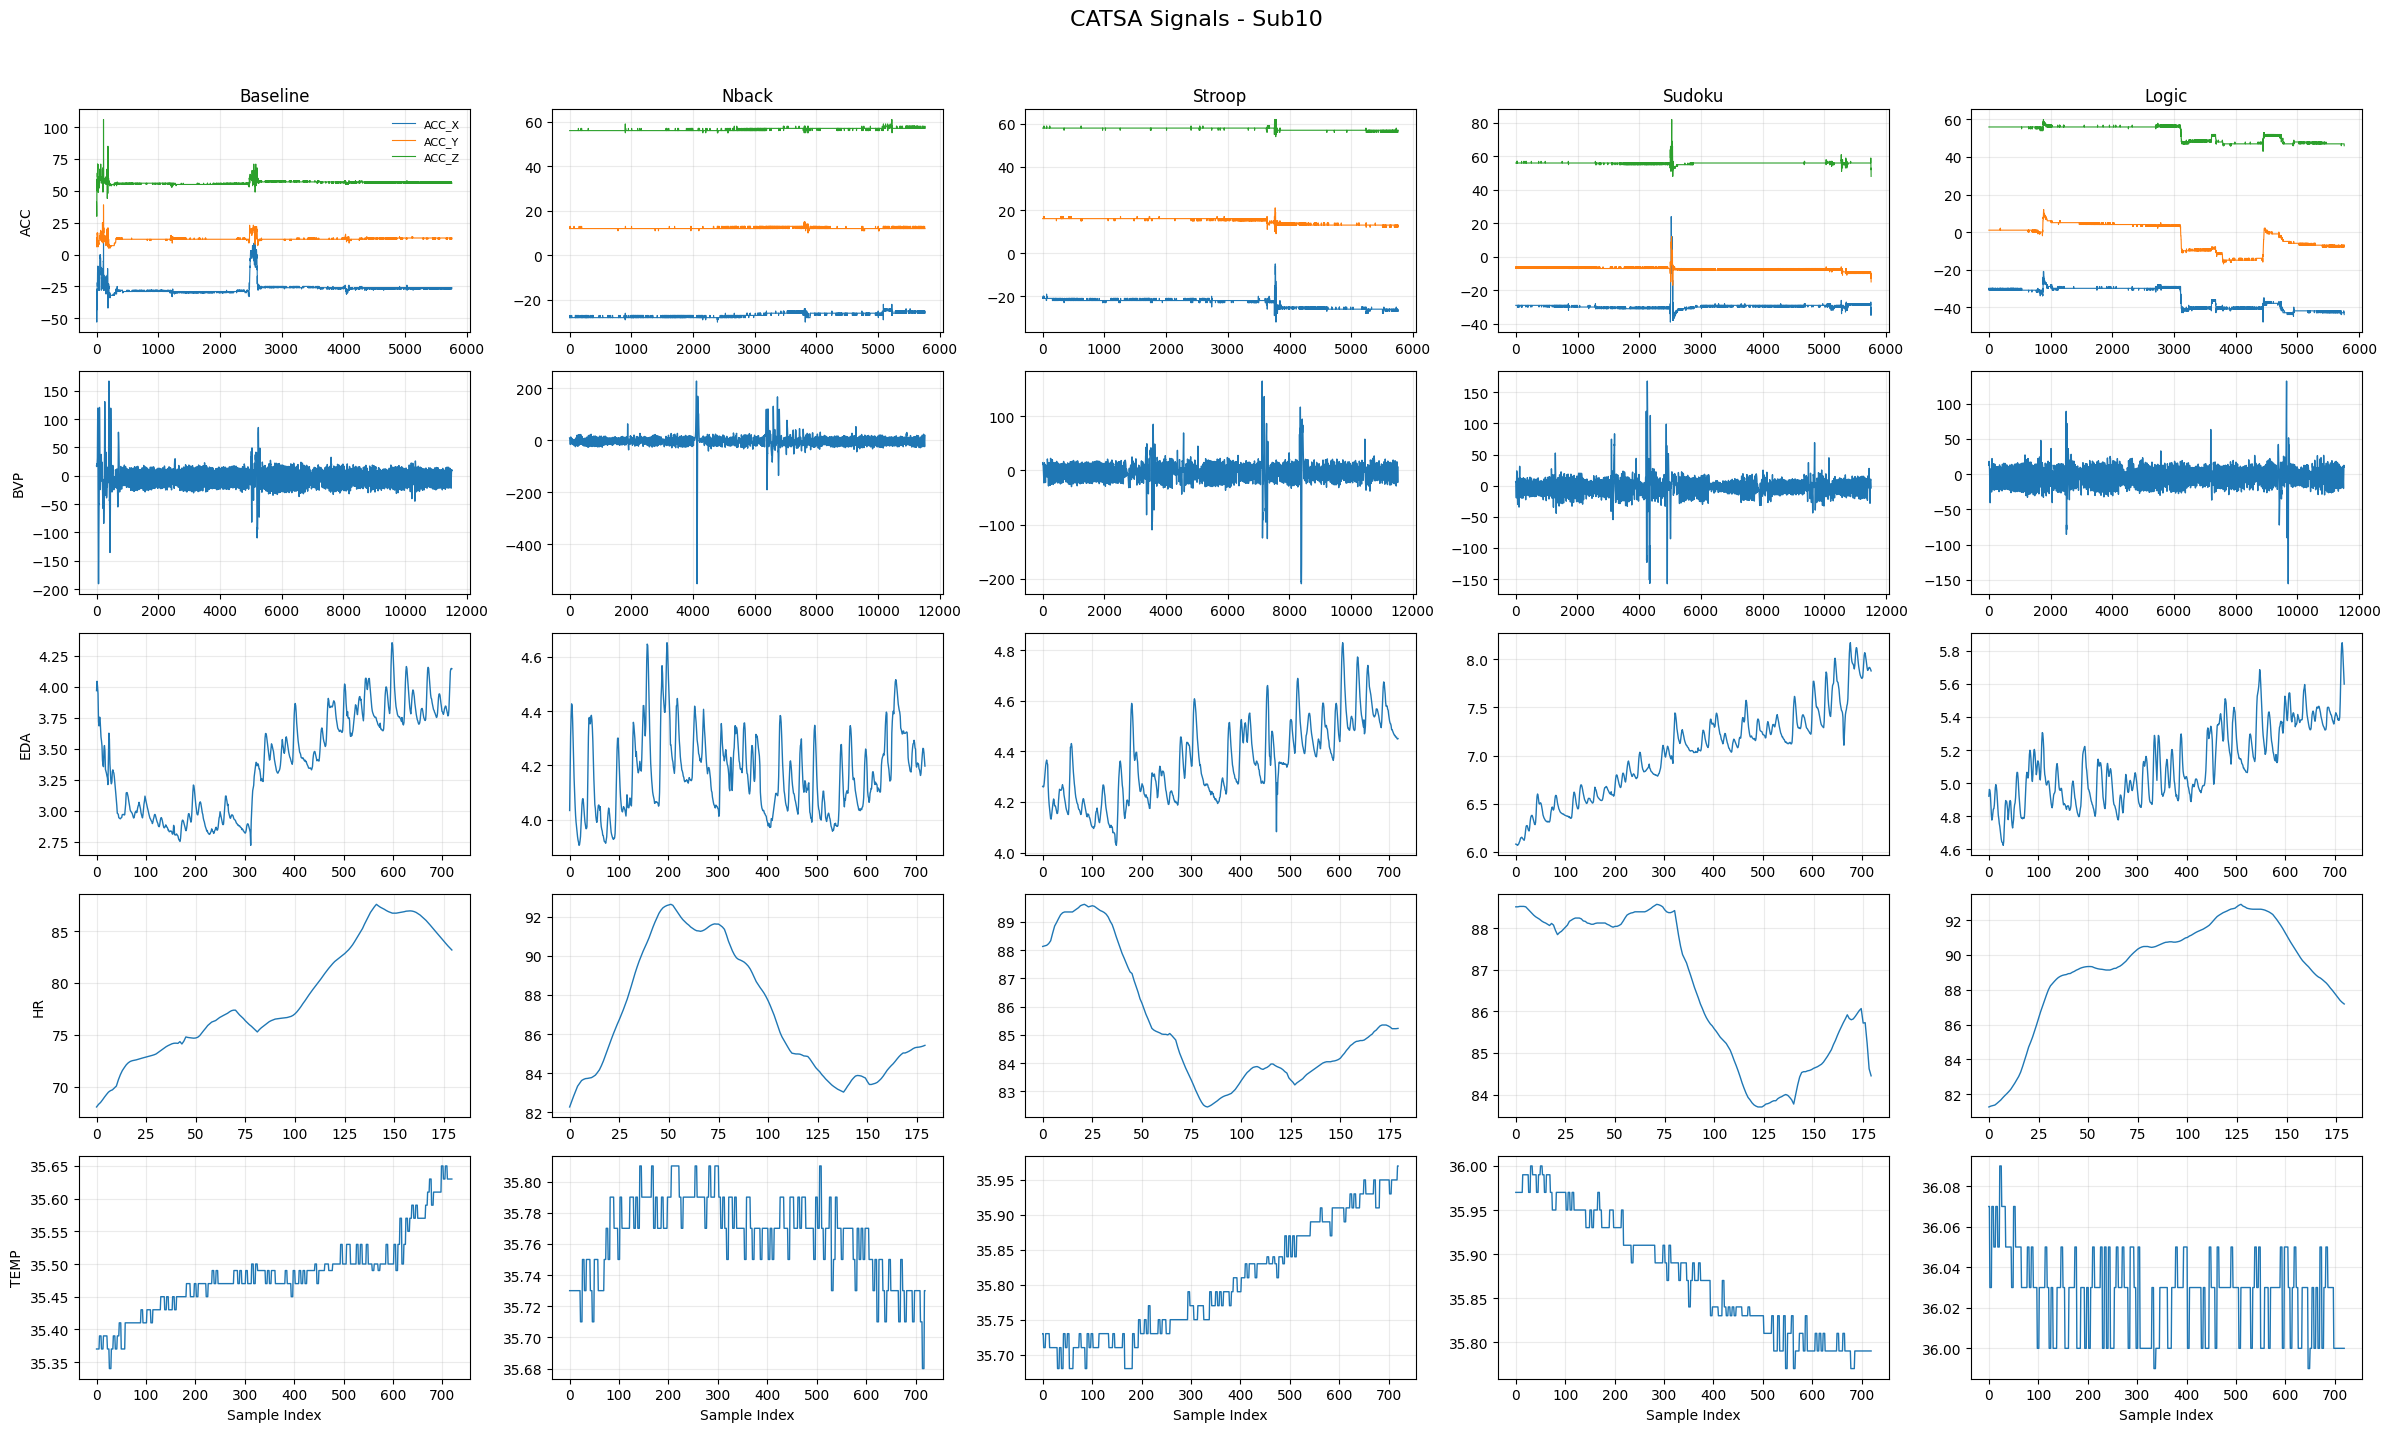

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASET_ROOT = Path('/home/binghin2/Myproject/Dataset/CATSA')
TASKS = ['Baseline', 'Nback', 'Stroop', 'Sudoku', 'Logic']
SENSORS = ['ACC', 'BVP', 'EDA', 'HR', 'TEMP']

SUBJECT_NUM = 10


def has_required_files(subj_dir: Path) -> bool:
    for task in TASKS:
        task_dir = subj_dir / task
        if not task_dir.exists():
            return False
        for sensor in SENSORS:
            if not (task_dir / f'{sensor}.csv').exists():
                return False
    return True


selected_subject = DATASET_ROOT / f'Sub{SUBJECT_NUM}'
if not selected_subject.exists() or not selected_subject.is_dir():
    raise RuntimeError(f'지정한 피험자 폴더를 찾지 못했습니다: {selected_subject.name}')

if not has_required_files(selected_subject):
    raise RuntimeError(
        f'{selected_subject.name} 폴더에 Baseline/Nback/Stroop/Sudoku/Logic 및 ACC/BVP/EDA/HR/TEMP 파일이 완전하지 않습니다.'
    )

print(f'Selected subject: {selected_subject.name}')

fig, axes = plt.subplots(len(SENSORS), len(TASKS), figsize=(24, 14), sharex=False)
fig.suptitle(f'CATSA Signals - {selected_subject.name}', fontsize=16, y=1.02)

for col, task in enumerate(TASKS):
    for row, sensor in enumerate(SENSORS):
        ax = axes[row, col]
        csv_path = selected_subject / task / f'{sensor}.csv'
        df = pd.read_csv(csv_path)

        if sensor == 'ACC':
            # ACC_X, ACC_Y, ACC_Z 3축을 함께 표시
            for c in df.columns:
                ax.plot(df[c].values, linewidth=0.8, label=c)
            if row == 0 and col == 0:
                ax.legend(loc='upper right', fontsize=8, frameon=False)
        else:
            series = df.iloc[:, 0].values
            ax.plot(series, linewidth=1.0, color='#1f77b4')

        if row == 0:
            ax.set_title(task)
        if col == 0:
            ax.set_ylabel(sensor)

        ax.grid(alpha=0.25)

for col in range(len(TASKS)):
    axes[-1, col].set_xlabel('Sample Index')

plt.tight_layout()
plt.show()

=== Task centroid cosine similarity ===
          Baseline   Nback  Stroop  Sudoku   Logic
Baseline    1.0000  0.3535  0.3792  0.3507  0.3716
Nback       0.3535  1.0000  0.9897  0.9931  0.9883
Stroop      0.3792  0.9897  1.0000  0.9970  0.9991
Sudoku      0.3507  0.9931  0.9970  1.0000  0.9984
Logic       0.3716  0.9883  0.9991  0.9984  1.0000


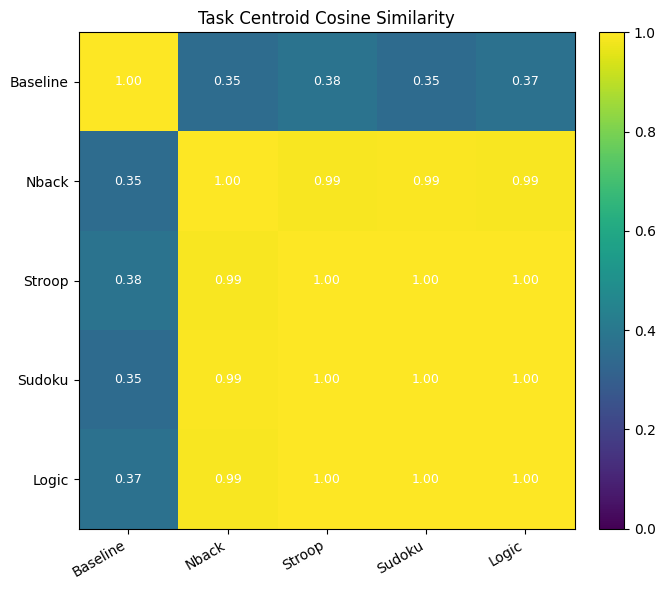


=== Baseline vs each stress-task cosine similarity (within-subject) ===
               mean     std  count
stress_task                       
Logic        0.8821  0.1759     50
Nback        0.9005  0.1845     50
Stroop       0.8787  0.1878     50
Sudoku       0.8761  0.1886     50


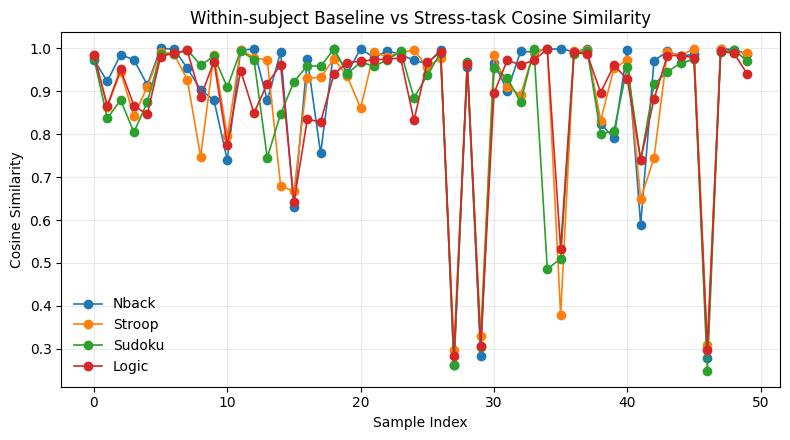


=== 2-class (Baseline vs Stress) LOSO CV ===
Accuracy:          0.7200 +/- 0.2653
Balanced Accuracy: 0.7050 +/- 0.2395
F1 score:          0.7455 +/- 0.3090


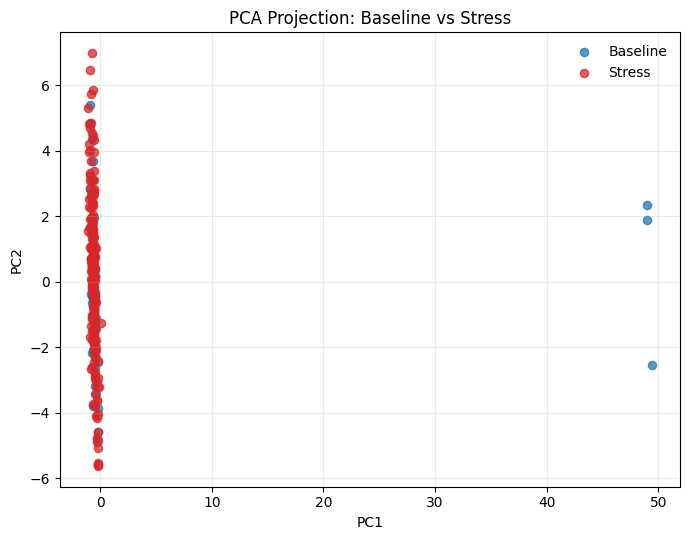


총 샘플 수: 250
label     task    
Baseline  Baseline    50
Stress    Logic       50
          Nback       50
          Stroop      50
          Sudoku      50
dtype: int64


In [2]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import LeaveOneGroupOut, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

STRESS_TASKS = [t for t in TASKS if t != 'Baseline']


def summarize_array(x: np.ndarray) -> list[float]:
    x = x[np.isfinite(x)]
    if x.size == 0:
        return [np.nan] * 8
    return [
        float(np.mean(x)),
        float(np.std(x)),
        float(np.min(x)),
        float(np.max(x)),
        float(np.median(x)),
        float(np.quantile(x, 0.25)),
        float(np.quantile(x, 0.75)),
        float(np.sqrt(np.mean(x**2))),
    ]


def extract_sensor_features(csv_path: Path) -> list[float]:
    df = pd.read_csv(csv_path)
    arr = df.to_numpy(dtype=float)
    if arr.ndim == 1:
        arr = arr[:, None]

    feats = []
    for col_idx in range(arr.shape[1]):
        feats.extend(summarize_array(arr[:, col_idx]))
    return feats


subject_dirs = sorted(
    [p for p in DATASET_ROOT.iterdir() if p.is_dir() and p.name.startswith('Sub')],
    key=lambda p: int(p.name.replace('Sub', '')),
)

rows = []
for subj in subject_dirs:
    for task in TASKS:
        task_dir = subj / task
        if not task_dir.exists():
            continue

        sample_feats = []
        missing = False
        for sensor in SENSORS:
            csv_path = task_dir / f'{sensor}.csv'
            if not csv_path.exists():
                missing = True
                break
            sample_feats.extend(extract_sensor_features(csv_path))

        if missing:
            continue

        rows.append(
            {
                'subject': subj.name,
                'task': task,
                'label': 'Baseline' if task == 'Baseline' else 'Stress',
                'y': 0 if task == 'Baseline' else 1,
                'features': np.array(sample_feats, dtype=float),
            }
        )

if not rows:
    raise RuntimeError('분석 가능한 샘플이 없습니다. 데이터 경로/파일 구성을 확인해주세요.')

analysis_df = pd.DataFrame(rows)
X = np.vstack(analysis_df['features'].values)
y = analysis_df['y'].to_numpy()
groups = analysis_df['subject'].to_numpy()

# 1) task centroid 유사도 (코사인)
task_centroids = {}
for task in TASKS:
    task_mask = analysis_df['task'] == task
    task_centroids[task] = np.mean(np.vstack(analysis_df.loc[task_mask, 'features']), axis=0)

centroid_mat = np.vstack([task_centroids[t] for t in TASKS])
sim_mat = cosine_similarity(centroid_mat)

print('=== Task centroid cosine similarity ===')
print(pd.DataFrame(sim_mat, index=TASKS, columns=TASKS).round(4))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_mat, cmap='viridis', vmin=0.0, vmax=1.0)
ax.set_xticks(range(len(TASKS)))
ax.set_yticks(range(len(TASKS)))
ax.set_xticklabels(TASKS, rotation=30, ha='right')
ax.set_yticklabels(TASKS)
ax.set_title('Task Centroid Cosine Similarity')
for i in range(len(TASKS)):
    for j in range(len(TASKS)):
        ax.text(j, i, f'{sim_mat[i, j]:.2f}', ha='center', va='center', color='white', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# 2) subject 내 Baseline vs 각 Stress task 유사도
base_vs_stress = []
for subj in sorted(analysis_df['subject'].unique(), key=lambda x: int(x.replace('Sub', ''))):
    subj_df = analysis_df[analysis_df['subject'] == subj]
    base_row = subj_df[subj_df['task'] == 'Baseline']
    if base_row.empty:
        continue
    base_feat = base_row.iloc[0]['features']

    for t in STRESS_TASKS:
        t_row = subj_df[subj_df['task'] == t]
        if t_row.empty:
            continue
        t_feat = t_row.iloc[0]['features']
        sim = cosine_similarity(base_feat.reshape(1, -1), t_feat.reshape(1, -1))[0, 0]
        base_vs_stress.append({'subject': subj, 'stress_task': t, 'cosine_sim': sim})

base_vs_stress_df = pd.DataFrame(base_vs_stress)
print('\n=== Baseline vs each stress-task cosine similarity (within-subject) ===')
print(base_vs_stress_df.groupby('stress_task')['cosine_sim'].agg(['mean', 'std', 'count']).round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
for t in STRESS_TASKS:
    vals = base_vs_stress_df.loc[base_vs_stress_df['stress_task'] == t, 'cosine_sim']
    ax.plot(vals.values, marker='o', linewidth=1.2, label=t)
ax.set_title('Within-subject Baseline vs Stress-task Cosine Similarity')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Cosine Similarity')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# 3) Baseline(0) vs Stress(1) 2-class 분류 성능 (LOSO)
logo = LeaveOneGroupOut()
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42),
)

scores = cross_validate(
    clf,
    X,
    y,
    cv=logo.split(X, y, groups=groups),
    scoring=['accuracy', 'balanced_accuracy', 'f1'],
    n_jobs=-1,
)

print('\n=== 2-class (Baseline vs Stress) LOSO CV ===')
print(f"Accuracy:          {scores['test_accuracy'].mean():.4f} +/- {scores['test_accuracy'].std():.4f}")
print(f"Balanced Accuracy: {scores['test_balanced_accuracy'].mean():.4f} +/- {scores['test_balanced_accuracy'].std():.4f}")
print(f"F1 score:          {scores['test_f1'].mean():.4f} +/- {scores['test_f1'].std():.4f}")

# 4) PCA 2D 시각화 (분리 정도 확인)
X_scaled = StandardScaler().fit_transform(X)
X_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
plot_df = pd.DataFrame({'pc1': X_2d[:, 0], 'pc2': X_2d[:, 1], 'label': analysis_df['label'], 'task': analysis_df['task']})

fig, ax = plt.subplots(figsize=(7, 5.5))
for label_name, color in [('Baseline', '#1f77b4'), ('Stress', '#d62728')]:
    part = plot_df[plot_df['label'] == label_name]
    ax.scatter(part['pc1'], part['pc2'], s=35, alpha=0.75, label=label_name, color=color)
ax.set_title('PCA Projection: Baseline vs Stress')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"\n총 샘플 수: {len(analysis_df)}")
print(analysis_df.groupby(['label', 'task']).size())